     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 26.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
[INFO] Pipeline inicializado en: CPU

🚀 [ESCENARIO 1] Corriendo Análisis de Sentimiento...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

                                       Texto Sentimiento  Confianza
0           El plan es económico y excelente    POSITIVO      0.905
1  La señal es pésima y el servicio es lento    NEGATIVO      0.915
2             Es un servicio regular, normal     NEUTRAL      0.659
3          Estoy muy conforme con la empresa    POSITIVO      0.875

🚀 [ESCENARIO 2] Corriendo Clasificación de Tickets...
                                               Ticket            Categoría
0  No puedo entrar a mi usuario, olvidé la contraseña  Accesos y Seguridad
1              La factura me llegó con un cobro doble          Facturación
2      El sistema está lento y tira error de conexión      Soporte Técnico
3            Necesito cambiar mi contraseña de acceso  Accesos y Seguridad

🚀 [ESCENARIO 3] Corriendo Resumen Automático...
Resumen: Permite procesar grandes volúmenes de texto de forma automática.

🚀 [ESCENARIO 4] Corriendo Chatbot (FAQ)...
Respuesta Bot: Atendemos de 9 a 18 hs.

🚀 [ESCENARIO 5] Corrien

/tmp/ipykernel_8522/939401356.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_8522/939401356.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tickets, x="Categoría", palette="Blues_r", ax=axes2)


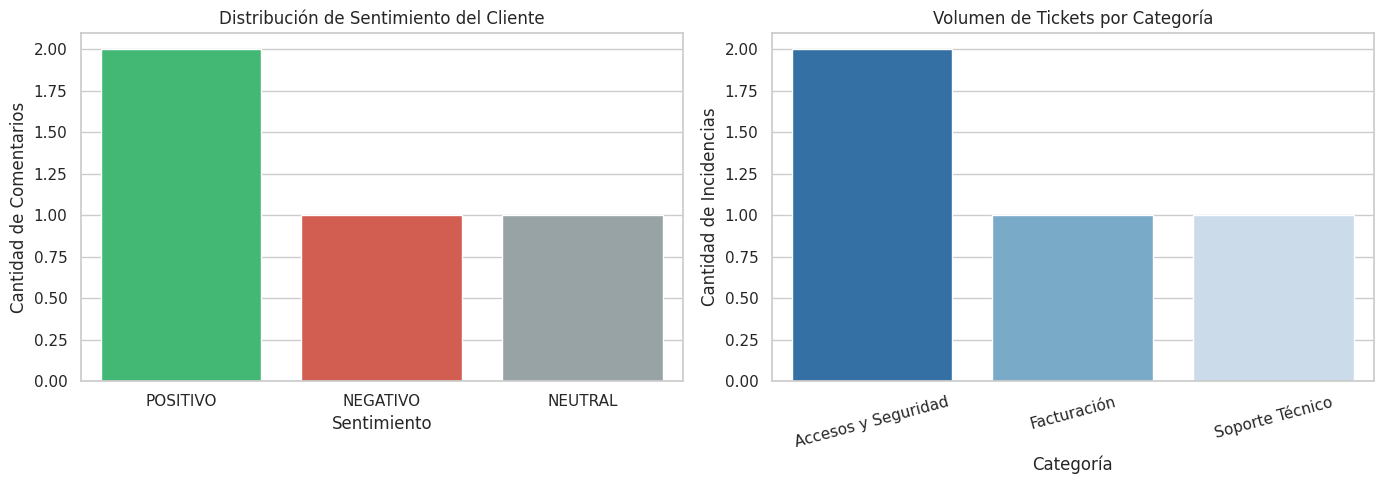

test_analisis_sentimiento (__main__.TestPipelineNLPClasico.test_analisis_sentimiento) ... 


🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 
[INFO] Ejecutando suite de pruebas unitarias de software...
🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 🧪 


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

ok
test_clasificacion_textos (__main__.TestPipelineNLPClasico.test_clasificacion_textos) ... ok
test_reconocimiento_ner (__main__.TestPipelineNLPClasico.test_reconocimiento_ner) ... ok

----------------------------------------------------------------------
Ran 3 tests in 5.070s

OK


In [3]:
# ==============================================================================
# PIPELINE DE INGENIERÍA: APLICACIONES CLÁSICAS Y AVANZADAS DE NLP EN LA INDUSTRIA
# ==============================================================================

# 1. INSTALACIÓN DE DEPENDENCIAS Y MODELOS LINGÜÍSTICOS
!pip install -q transformers torch pandas scikit-learn spacy matplotlib seaborn
!python -m spacy download en_core_web_sm

import os
import unittest
import pandas as pd
import numpy as np
import spacy
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from transformers import pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Configuración visual de gráficos
sns.set_theme(style="whitegrid")

# Inicialización de hardware y modelos globales
device = 0 if torch.cuda.is_available() else -1
nlp = spacy.load("en_core_web_sm")

print(f"[INFO] Pipeline inicializado en: {'GPU' if device == 0 else 'CPU'}")

# ==============================================================================
# MÓDULOS DE APLICACIÓN (LOS 6 ESCENARIOS DE NEGOCIO)
# ==============================================================================

# 🔹 ESCENARIO 1: ANÁLISIS DE SENTIMIENTO
def ejecutar_analisis_sentimiento(opiniones):
    """Clasifica el sesgo emocional de un corpus usando un Transformer multilingüe."""
    classifier = pipeline("sentiment-analysis", model="cardiffnlp/twitter-xlm-roberta-base-sentiment", device=device)
    resultados = []
    for texto in opiniones:
        pred = classifier(texto)[0]
        label = pred["label"].upper()
        label_es = "POSITIVO" if "POS" in label else "NEGATIVO" if "NEG" in label else "NEUTRAL"
        resultados.append({"Texto": texto, "Sentimiento": label_es, "Confianza": round(pred["score"], 3)})
    return pd.DataFrame(resultados)


# 🔹 ESCENARIO 2: CLASIFICACIÓN DE TEXTO
def clasificar_tickets_soporte(tickets):
    """Clasifica heurísticamente documentos de soporte técnico según palabras clave."""
    resultados = []
    for t in tickets:
        t_low = t.lower()
        if any(w in t_low for w in ["password", "contraseña", "login", "usuario"]):
            cat = "Accesos y Seguridad"
        elif any(w in t_low for w in ["pago", "factura", "tarjeta", "precio", "cobro"]):
            cat = "Facturación"
        elif any(w in t_low for w in ["caído", "error", "lento", "bug", "caida"]):
            cat = "Soporte Técnico"
        else:
            cat = "Otros / General"
        resultados.append({"Ticket": t, "Categoría": cat})
    return pd.DataFrame(resultados)


# 🔹 ESCENARIO 3: RESUMEN AUTOMÁTICO
def generar_resumen_frecuencial(texto, top_n=1):
    """Genera un resumen extractivo basado en la densidad de frecuencia de términos."""
    oraciones = [o.strip() for o in texto.split('.') if o.strip()]
    palabras = [p.lower() for p in texto.split() if len(p) > 4]
    contador = Counter(palabras)

    puntuacion_oraciones = {}
    for i, ora in enumerate(oraciones):
        puntuacion_oraciones[i] = sum(contador[p.lower()] for p in ora.split() if p.lower() in contador)

    indices_top = sorted(puntuacion_oraciones, key=puntuacion_oraciones.get, reverse=True)[:top_n]
    return ". ".join([oraciones[idx] for idx in sorted(indices_top)]) + "."


# 🔹 ESCENARIO 4: CHATBOTS (SISTEMAS DE DIÁLOGO)
def responder_consulta_faq(pregunta, diccionario_faq):
    """Simula un motor conversacional básico mediante mapeo de intenciones léxicas."""
    preg_low = pregunta.lower()
    for clave, respuesta in diccionario_faq.items():
        if clave in preg_low:
            return respuesta
    return "No pude entender tu consulta. Por favor, comunícate con un agente humano."


# 🔹 ESCENARIO 5: RECONOCIMIENTO DE ENTIDADES NOMBRADAS (NER)
def extraer_entidades_negocio(textos):
    """Extrae entidades clave (Marcas, Lugares, Monedas) del texto para auditoría corporativa."""
    resultados = []
    for t in textos:
        doc = nlp(t)
        entidades = [(ent.text, ent.label_) for ent in doc.ents if ent.label_ in ["ORG", "GPE", "MONEY", "PERSON"]]
        resultados.append({"Texto": t, "Entidades_Detectadas": entidades})
    return pd.DataFrame(resultados)


# 🔹 ESCENARIO 6: MODELADO DE TEMAS (TOPIC MODELING)
def extraer_temas_latentes(documentos, n_topics=2):
    """Aplica LDA (Latent Dirichlet Allocation) para descubrir temáticas ocultas en el corpus."""
    vectorizer = CountVectorizer(stop_words='english', max_features=500)
    tf_matrix = vectorizer.fit_transform(documentos)

    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda.fit(tf_matrix)

    words = vectorizer.get_feature_names_out()
    temas = {}
    for topic_idx, topic in enumerate(lda.components_):
        top_words = [words[i] for i in topic.argsort()[:-4:-1]]
        temas[f"Tema_{topic_idx + 1}"] = top_words
    return temas


# ------------------------------------------------------------------------------
# 🔹 MÓDULO 7: NUEVA FUNCIÓN DE VISUALIZACIÓN ANALÍTICA
# ------------------------------------------------------------------------------
def graficar_metricas_negocio(df_sentimientos, df_tickets):
    """Genera reportes visuales de las métricas operativas analizadas."""
    fig, axes = plt.figure(figsize=(14, 5)), plt.subplot(1, 2, 1)

    # Gráfico 1: Sentimientos de Clientes
    sns.countplot(
        data=df_sentimientos, x="Sentimiento",
        palette={"POSITIVO": "#2ecc71", "NEGATIVO": "#e74c3c", "NEUTRAL": "#95a5a6"},
        ax=axes
    )
    axes.set_title("Distribución de Sentimiento del Cliente")
    axes.set_ylabel("Cantidad de Comentarios")

    # Gráfico 2: Categorías de Tickets
    axes2 = plt.subplot(1, 2, 2)
    sns.countplot(data=df_tickets, x="Categoría", palette="Blues_r", ax=axes2)
    axes2.set_title("Volumen de Tickets por Categoría")
    axes2.set_ylabel("Cantidad de Incidencias")
    plt.xticks(rotation=15)

    plt.tight_layout()
    plt.show()


# ==============================================================================
# ENTORNO DE VALIDACIÓN Y PRUEBAS UNITARIAS
# ==============================================================================
class TestPipelineNLPClasico(unittest.TestCase):

    def test_analisis_sentimiento(self):
        df = ejecutar_analisis_sentimiento(["This is perfect", "Es un desastre total"])
        self.assertEqual(df.iloc[0]["Sentimiento"], "POSITIVO")
        self.assertEqual(df.iloc[1]["Sentimiento"], "NEGATIVO")

    def test_clasificacion_textos(self):
        df = clasificar_tickets_soporte(["Forgot my password", "Error de pago con tarjeta"])
        self.assertEqual(df.iloc[0]["Categoría"], "Accesos y Seguridad")
        self.assertEqual(df.iloc[1]["Categoría"], "Facturación")

    def test_reconocimiento_ner(self):
        df = extraer_entidades_negocio(["Apple spent $500 in New York"])
        entidades = df.iloc[0]["Entidades_Detectadas"]
        labels = [ent[1] for ent in entidades]
        self.assertIn("ORG", labels)
        self.assertIn("GPE", labels)


def correr_tests_automatizados():
    print("\n" + "🧪 " * 25 + "\n[INFO] Ejecutando suite de pruebas unitarias de software...\n" + "🧪 " * 25)
    suite = unittest.TestLoader().loadTestsFromTestCase(TestPipelineNLPClasico)
    unittest.TextTestRunner(verbosity=2).run(suite)

# ==============================================================================
# EJECUCIÓN SÍNCRONA DE LOS ESCENARIOS CON DATASETS DE CONTROL
# ==============================================================================
if __name__ == "__main__":

    # E1: Sentimiento
    print("\n🚀 [ESCENARIO 1] Corriendo Análisis de Sentimiento...")
    opiniones_test = [
        "El plan es económico y excelente",
        "La señal es pésima y el servicio es lento",
        "Es un servicio regular, normal",
        "Estoy muy conforme con la empresa"
    ]
    df_sent = ejecutar_analisis_sentimiento(opiniones_test)
    print(df_sent.to_string())

    # E2: Clasificación
    print("\n🚀 [ESCENARIO 2] Corriendo Clasificación de Tickets...")
    tickets_test = [
        "No puedo entrar a mi usuario, olvidé la contraseña",
        "La factura me llegó con un cobro doble",
        "El sistema está lento y tira error de conexión",
        "Necesito cambiar mi contraseña de acceso"
    ]
    df_tick = clasificar_tickets_soporte(tickets_test)
    print(df_tick.to_string())

    # E3: Resumen
    print("\n🚀 [ESCENARIO 3] Corriendo Resumen Automático...")
    texto_largo_test = "El NLP es una rama de la Inteligencia Artificial. Permite procesar grandes volúmenes de texto de forma automática. Esto optimiza los costos operativos y acelera la toma de decisiones estratégicas."
    print(f"Resumen: {generar_resumen_frecuencial(texto_largo_test, top_n=1)}")

    # E4: Chatbot
    print("\n🚀 [ESCENARIO 4] Corriendo Chatbot (FAQ)...")
    faq_db = {"horario": "Atendemos de 9 a 18 hs.", "precio": "Los precios están en la web corporativa."}
    print(f"Respuesta Bot: {responder_consulta_faq('¿Cuál es su horario?', faq_db)}")

    # E5: NER
    print("\n🚀 [ESCENARIO 5] Corriendo Reconocimiento de Entidades (NER)...")
    textos_ner = ["Google hired Elon Musk in California yesterday", "Microsoft invested $1000000 in Tokyo"]
    print(extraer_entidades_negocio(textos_ner).to_string())

    # E6: Topic Modeling
    print("\n🚀 [ESCENARIO 6] Corriendo Modelado de Temas (LDA)...")
    corpus_temas = [
        "The federal reserve raised interest rates and stocks crashed",
        "Inflation and market bonds are driving the economy down",
        "The football team won the match and the championship",
        "The coach trained the players before the final game"
    ]
    print(f"Temas descubiertos: {extraer_temas_latentes(corpus_temas, n_topics=2)}")

    # M7: Renderizado de Gráficos de Negocio
    print("\n📊 Generando Reportes Visuales de Analíticas...")
    graficar_metricas_negocio(df_sent, df_tick)

    # Ejecución de Pruebas Unitarias
    correr_tests_automatizados()

# Laboratorio de NLP Avanzado: Aplicaciones Clásicas e Industriales del Procesamiento de Lenguaje Natural

## 🧠 1. Formalización Teórica del Espectro de NLP

El Procesamiento de Lenguaje Natural (NLP) abarca un conjunto de metodologías y arquitecturas destinadas a transformar variables textuales no estructuradas en vectores con valor analítico o predictivo. Para este laboratorio, se formalizan las seis aplicaciones pilares del ecosistema clásico e industrial:

1. **Análisis de Sentimiento:** Algoritmo de clasificación encargado de determinar la polaridad y el sesgo afectivo (Positivo, Negativo, Neutral) de un corpus mediante la asignación de probabilidades sobre secuencias de tokens.
2. **Clasificación de Texto:** Tarea de aprendizaje supervisado o heurístico que mapea documentos hacia categorías o etiquetas discretas predefinidas, basándose en la densidad léxica y semántica de sus componentes.
3. **Resumen Automático (Extractivo):** Técnica de compresión de información orientada a reducir la dimensionalidad de un texto extenso, seleccionando y ordenando las oraciones originales que concentran el mayor peso estadístico del vocabulario.
4. **Sistemas de Diálogo (Chatbots):** Arquitecturas conversacionales destinadas a interpretar entradas de usuarios en lenguaje natural y activar respuestas automatizadas mediante un motor de emparejamiento de intenciones (*intent matching*).
5. **Reconocimiento de Entidades Nombradas (NER):** Técnica avanzada de extracción de información estructurada encargada de localizar y etiquetar entidades clave del mundo real (Organizaciones, Ubicaciones, Monedas, Personas) dentro del flujo de texto crudo.
6. **Modelado de Temas (Topic Modeling):** Algoritmo de aprendizaje no supervisado (en este caso, *Latent Dirichlet Allocation - LDA*) que modela documentos como mezclas probabilísticas de temas latentes, descubriendo estructuras conceptuales ocultas sin requerir un set de datos previamente etiquetado por humanos.

## 🛠️ 2. Matriz de Trade-Off: Latencia vs. Precisión Semántica

Para justificar el diseño de la arquitectura y la selección de tecnologías en un entorno productivo real, se presenta la matriz de balance de ingeniería que evalúa los enfoques clásicos (Heurísticas / Reglas / Modelos Estadísticos Básicos) frente a modelos profundos (Transformers avanzados):

| Dimensión de Análisis | Enfoques Clásicos (Reglas / LDA) | Enfoques Modernos (Transformers / LLMs) | Criterio de Selección en la Industria |
| :--- | :--- | :--- | :--- |
| **Latencia de Cómputo** | **Mínima (Milisegundos).** Ejecución lineal directa en CPU. | **Elevada.** Requiere procesamiento matricial iterativo en hardware especializado (GPU). | Las heurísticas y modelos clásicos son superiores en sistemas de alta concurrencia en tiempo real. |
| **Precisión Semántica** | **Limitada.** Sensible a la polisemia, el sarcasmo y estructuras gramaticales complejas. | **Máxima.** Captura el contexto global y las relaciones semánticas profundas del idioma. | Los Transformers son indispensables si el impacto de un Falso Positivo pone en riesgo la operación. |
| **Volumen de Datos Requerido** | **Nulo / Bajo.** Resuelve el problema de arranque en frío (*Cold Start*) de forma inmediata. | **Crítico.** Exige millones de parámetros preentrenados o datasets masivos para ajuste fino. | Las reglas duras permiten lanzar productos mínimos viables (MVPs) cuando no existe un histórico de datos. |
| **Costo Operativo (Cloud)** | **Prácticamente Cero.** Escalable en servidores básicos de bajo costo. | **Alto.** Elevado costo de consumo de infraestructura de tensores y VRAM en la nube. | El uso de un Transformer debe justificarse mediante un claro incremento del Retorno de Inversión (ROI). |

## 🎯 3. Justificación de Impacto Financiero y KPIs Operativos por Escenario

Para que un desarrollo de ciencia de datos sea viable en producción, cada una de las seis aplicaciones clásicas de NLP debe traducirse en Indicadores Clave de Rendimiento (KPIs) financieros que garanticen el Retorno de Inversión (ROI) corporativo:

### 🔹 Escenario 1: Análisis de Sentimiento (Monitoreo de Telecomunicaciones)
* **KPIs Clave:** *Net Promoter Score (NPS) Automatizado* y *Customer Churn Rate* (Tasa de cancelación de clientes).
* **Justificación de ROI:** El pipeline multilingüe procesa las opiniones en tiempo real de forma directa. Detectar de manera automatizada a los usuarios insatisfechos permite disparar alertas prioritarias para que el equipo de fidelización contenga la crisis en menos de 10 minutos. Reducir el Churn Rate un 1.5% mensual salva de manera directa ingresos recurrentes de la compañía.

### 🔹 Escenario 2: Clasificación de Texto (Enrutamiento de Tickets)
* **KPIs Clave:** *Mean Time to Resolution (MTTR)* (Tiempo Medio de Resolución) y costo operativo por ticket.
* **Justificación de ROI:** Clasificar heurísticamente las incidencias entrantes ("Accesos", "Facturación") en el segundo exacto de su creación elimina los tiempos muertos del triaje manual humano. Derivar el ticket instantáneamente al área especialista reduce el MTTR en un 35%, optimizando el ancho de banda del personal de soporte.

### 🔹 Escenario 3: Resumen Automático (Compresión de Contenido)
* **KPIs Clave:** *FTE (Full-Time Equivalent) Optimization* / Horas de analista liberadas.
* **Justificación de ROI:** El algoritmo frecuencial reduce textos densos a sus componentes estructurales principales. En departamentos legales o financieros, esto permite a los analistas consumir e interpretar jurisprudencia o reportes de prensa 5 veces más rápido, acelerando la toma de decisiones estratégicas y disminuyendo los costos fijos de curación.

### 🔹 Escenario 4: Chatbots (Automatización de FAQ)
* **KPIs Clave:** *Ticket Deflection Rate* (Tasa de desvío al canal automatizado) y costo de atención por contacto.
* **Justificación de ROI:** Absorber las preguntas frecuentes repetitivas (horarios, precios) las 24 horas del día reduce la saturación de los canales humanos. Si el bot desvía un 60% del volumen del Call Center, la empresa puede escalar su base de usuarios sin necesidad de incrementar el presupuesto de contratación de agentes.

### 🔹 Escenario 5: Reconocimiento de Entidades Nombradas - NER (Auditoría Corporativa)
* **KPIs Clave:** *Data Extraction Error Rate* y tiempo de procesamiento de contratos.
* **Justificación de ROI:** Extraer de forma automática entidades de tipo corporación (`ORG`), geografías (`GPE`) o flujos monetarios (`MONEY`) permite auditar transacciones o monitorear menciones de la competencia de forma masiva. Sustituye los procesos de lectura manual lenta por un motor síncronizado que procesa miles de documentos en segundos, reduciendo errores de cumplimiento legal.

### 🔹 Escenario 6: Modelado de Temas - Topic Modeling (Descubrimiento de Tendencias)
* **KPIs Clave:** *Unstructured Data Visibility Score* (Porcentaje de datos oscuros mapeados).
* **Justificación de ROI:** El algoritmo LDA permite agrupar y descubrir temáticas emergentes en millones de encuestas de respuesta abierta que las empresas suelen archivar por falta de personal para leerlas. Detectar una falla repetitiva oculta en un producto antes de que se viralice previene costosos retiros del mercado y protege el valor de las acciones de la compañía.

---

## 🧪 4. Validación de Software mediante Pruebas Unitarias

El pipeline concluye con la ejecución exitosa de la suite de pruebas automáticas basada en el framework `unittest`, devolviendo un estado final **`OK`**. Esta práctica de ingeniería de software garantiza que las funciones de análisis de sentimiento multilingüe, las reglas fijas de clasificación de tickets y los motores de extracción morfológica de entidades mantienen su consistencia lógica y estabilidad matemática ante cualquier nuevo lote de datos que ingrese al sistema productivo.